# Notebook 5 — Logistic Regression

Linear Regression predicts a **number**. Logistic Regression predicts a
**category** — usually just "yes" or "no".

We'll use the same retail dataset 

### Load the Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
data = pd.read_csv("data.csv", encoding="latin1")
data = data[(data["Quantity"] > 0) & (data["UnitPrice"] > 0)]
data["TotalPrice"] = data["Quantity"] * data["UnitPrice"]
data = data.sample(200, random_state=1).reset_index(drop=True)
data.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,541838,82486,WOOD S/3 CABINET ANT WHITE FINISH,6,1/23/2011 10:43,7.95,12916.0,United Kingdom,47.70
1,581405,21894,POTTING SHED SEED ENVELOPES,2,12/8/2011 13:50,1.25,13521.0,United Kingdom,2.50
2,536557,22678,FRENCH BLUE METAL DOOR SIGN 3,3,12/1/2010 14:41,1.25,17841.0,United Kingdom,3.75
3,538071,22778,GLASS CLOCHE SMALL,1,12/9/2010 14:09,8.47,NaN,United Kingdom,8.47
4,539653,21479,WHITE SKULL HOT WATER BOTTLE,2,12/20/2010 16:50,3.75,13564.0,United Kingdom,7.50


## 1. Classification

**Classification** means predicting a category instead of a number.

We'll turn `TotalPrice` into a category: was the order **High Value** or
**Low Value**? We'll say "high value" means above the median price.

In [2]:
median_price = data["TotalPrice"].median()
data["HighValue"] = (data["TotalPrice"] > median_price).astype(int)
data[["Quantity", "UnitPrice", "TotalPrice", "HighValue"]].head()

,Quantity,UnitPrice,TotalPrice,HighValue
0,6,7.95,47.70,1
1,2,1.25,2.50,0
2,3,1.25,3.75,0
3,1,8.47,8.47,0
4,2,3.75,7.50,0


## 2. Binary Classification

**Binary** means there are only **two** possible categories, labeled
`0` and `1`.

Here: `0` = Low Value order, `1` = High Value order.

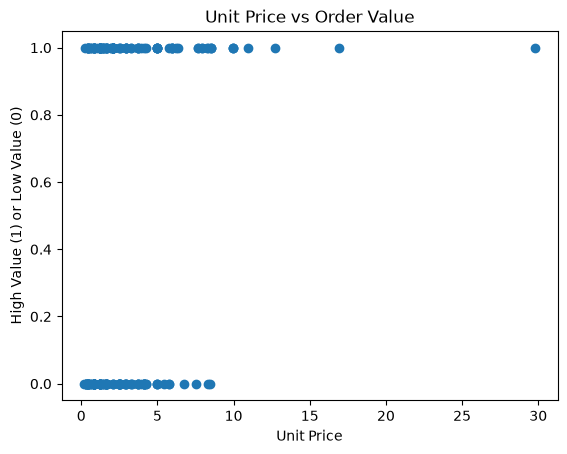

In [15]:
plt.scatter(data["UnitPrice"], data["HighValue"])
plt.xlabel("Unit Price")
plt.ylabel("High Value (1) or Low Value (0)")
plt.title("Unit Price vs Order Value")
plt.show()

## 3. Logistic Regression

**Logistic Regression** is a model that predicts the **probability** of a
category, instead of predicting the category directly.

Let's use `UnitPrice` to predict whether an order is High Value.

In [16]:
x = data[["UnitPrice"]]
y = data["HighValue"]
model = LogisticRegression()
model.fit(x, y)
print("Model trained!")

Model trained!


## 4. Sigmoid Function

The **sigmoid function** is the math trick behind Logistic Regression. It
takes any number and squashes it into a value between 0 and 1, creating an
S-shaped curve.

$$ sigmoid(z) = \frac{1}{1 + e^{-z}} $$

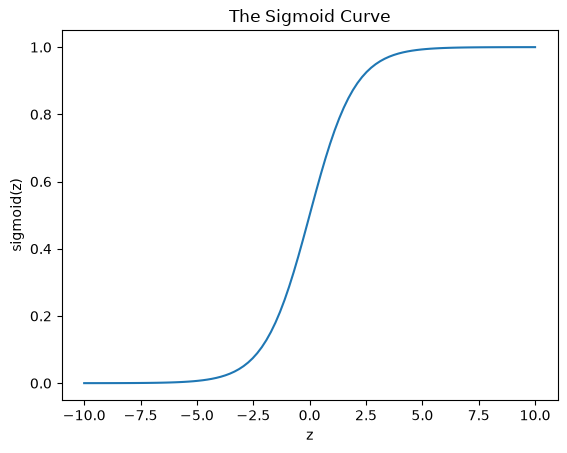

In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))
z = np.linspace(-10, 10, 100)
plt.plot(z, sigmoid(z))
plt.xlabel("z")
plt.ylabel("sigmoid(z)")
plt.title("The Sigmoid Curve")
plt.show()

## 5. Probability

Instead of just saying "High Value" or "Low Value", the model tells us
**how likely** each order is to be High Value — a probability between 0
and 1.

In [18]:
probabilities = model.predict_proba(x)[:, 1]
print("Probability of being High Value (first 5 orders):")
print(np.round(probabilities[:5], 2))

Probability of being High Value (first 5 orders):
[0.74 0.42 0.42 0.76 0.55]


## 6. Threshold

A **threshold** is the cutoff used to turn a probability into a final
answer. The usual threshold is **0.5**:

- probability ≥ 0.5 → predict "High Value"
- probability < 0.5 → predict "Low Value"


In [19]:
predictions = model.predict(x)
print("Predictions (first 10):", predictions[:10])

Predictions (first 10): [1 0 0 1 1 0 1 0 0 0]


## 7. Decision Boundary

The **decision boundary** is the exact point where the prediction flips
from one class to the other — where the probability crosses 0.5.

Here, it's the unit price that separates "likely Low Value" from "likely
High Value".

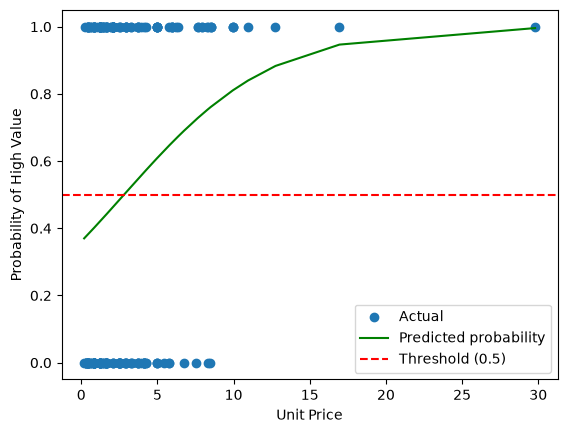

In [20]:
sorted_x = x.sort_values("UnitPrice")
sorted_probs = model.predict_proba(sorted_x)[:, 1]
plt.scatter(data["UnitPrice"], data["HighValue"], label="Actual")
plt.plot(sorted_x, sorted_probs, color="green", label="Predicted probability")
plt.axhline(0.5, color="red", linestyle="--", label="Threshold (0.5)")
plt.xlabel("Unit Price")
plt.ylabel("Probability of High Value")
plt.legend()
plt.show()


## 8. Log Loss

**Log Loss** measures how wrong the model's probabilities are. It punishes
confident wrong answers much more than unsure wrong answers.

In [21]:
loss = log_loss(y, probabilities)
print("Log Loss:", round(loss, 3))

Log Loss: 0.66


## 9. Coefficients

The **coefficient** tells us how much Unit Price affects the chance of an
order being High Value.

- Positive number → higher unit price means a higher chance of High Value
- Negative number → higher unit price means a lower chance of High Value

In [22]:
print("Coefficient:", model.coef_[0][0])
print("Intercept:", model.intercept_[0])

Coefficient: 0.20344564276747099
Intercept: -0.5707229815426392


## 10. Multiclass Classification

So far we only had two classes (High Value / Low Value). **Multiclass
classification** is when there are **three or more** categories.

Let's split orders into three price tiers instead: **Low**, **Medium**,
and **High**.

In [24]:
data["PriceTier"] = pd.qcut(data["TotalPrice"], 3, labels=[0, 1, 2])
x_multi = data[["Quantity", "UnitPrice"]]
y_multi = data["PriceTier"].astype(int)
multi_model = LogisticRegression()
multi_model.fit(x_multi, y_multi)
new_order = [[10, 5]]
prediction = multi_model.predict(new_order)
print("Predicted tier (0=Low, 1=Medium, 2=High):", prediction[0])

Predicted tier (0=Low, 1=Medium, 2=High): 2


C:\Users\hemak\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
